In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
train_dir = "/content/drive/MyDrive/training"
val_dir   = "/content/drive/MyDrive/validation"

train_csv = "/content/drive/MyDrive/ISIC-2017_Training_Part3_GroundTruth.csv"
val_csv   = "/content/drive/MyDrive/ISIC-2017_Validation_Part3_GroundTruth.csv"

In [ ]:
import os
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)

print(train_df.head())

       image_id  melanoma  seborrheic_keratosis
0  ISIC_0000000       0.0                   0.0
1  ISIC_0000001       0.0                   0.0
2  ISIC_0000002       1.0                   0.0
3  ISIC_0000003       0.0                   0.0
4  ISIC_0000004       1.0                   0.0


In [ ]:
# Add .jpg to image_id
train_df["filename"] = train_df["image_id"] + ".jpg"
val_df["filename"] = val_df["image_id"] + ".jpg"

# Create full path
train_df["filepath"] = train_df["filename"].apply(lambda x: os.path.join(train_dir, x))
val_df["filepath"] = val_df["filename"].apply(lambda x: os.path.join(val_dir, x))

# Use melanoma column as label
train_df["label"] = train_df["melanoma"]
val_df["label"] = val_df["melanoma"]

# Remove missing files
train_df = train_df[train_df["filepath"].apply(os.path.exists)]
val_df = val_df[val_df["filepath"].apply(os.path.exists)]

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Train size: 2000
Val size: 150


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df["filepath"].values, train_df["label"].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df["filepath"].values, val_df["label"].values)
)

train_ds = train_ds.map(load_image).map(augment).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 628s 10s/step - accuracy: 0.7815 - auc: 0.5408 - loss: 0.6064 - val_accuracy: 0.8000 - val_auc: 0.5968 - val_loss: 0.5487
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 387s 6s/step - accuracy: 0.8130 - auc: 0.5772 - loss: 0.5087 - val_accuracy: 0.8000 - val_auc: 0.6118 - val_loss: 0.5712
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 386s 6s/step - accuracy: 0.8150 - auc: 0.5527 - loss: 0.5144 - val_accuracy: 0.8000 - val_auc: 0.3667 - val_loss: 0.5751
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 384s 6s/step - accuracy: 0.8145 - auc: 0.5403 - loss: 0.5119 - val_accuracy: 0.8000 - val_auc: 0.4485 - val_loss: 0.5846
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 385s 6s/step - accuracy: 0.8145 - auc: 0.5834 - loss: 0.5114 - val_accuracy: 0.8000 - val_auc: 0.4429 - val_loss: 0.5379
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 369s 6s/step - accuracy: 0.8125 - auc: 0.5739 - loss: 0.4984 - val_accuracy: 0.8000 - val_auc: 0.6579 - val_loss: 0.5183
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 384s 6s

In [ ]:
model.save("melanoma_model.h5")

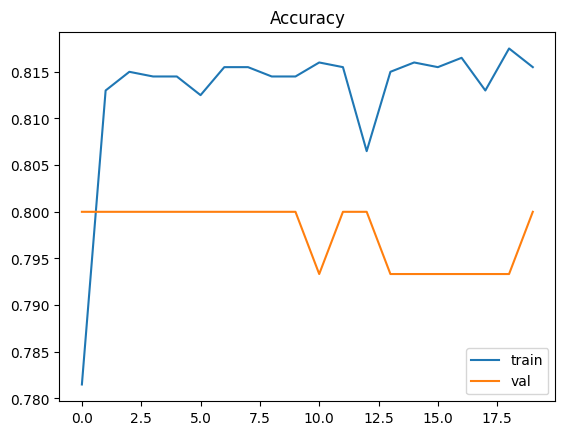

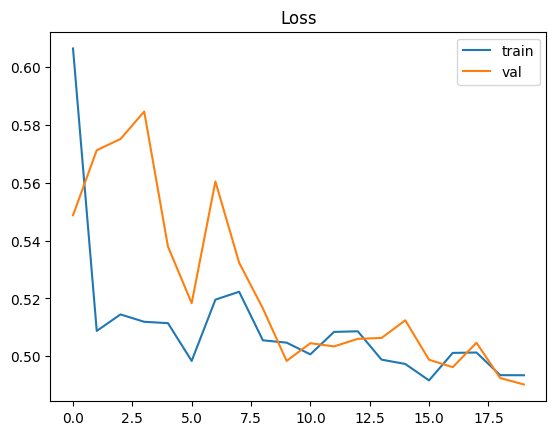

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.savefig("accuracy.png")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.savefig("loss.png")
plt.show()

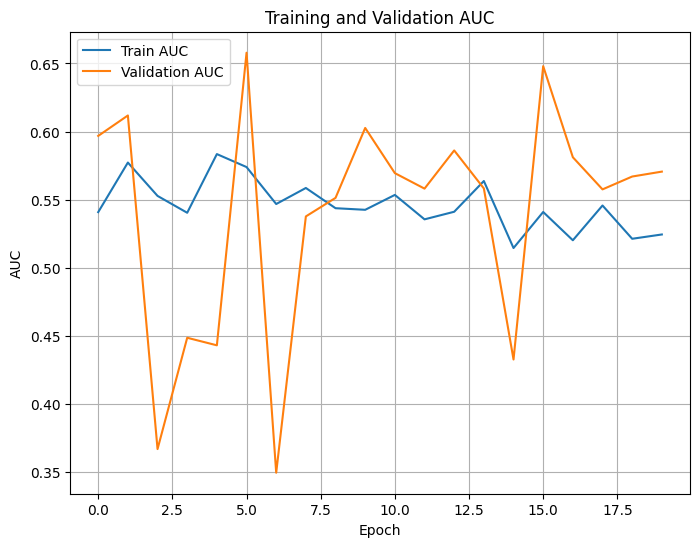

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Training and Validation AUC")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_true = val_df["label"].values

y_pred_prob = model.predict(val_ds).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)


5/5 ━━━━━━━━━━━━━━━━━━━━ 29s 5s/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 45s 10s/step
Confusion Matrix:
[[120   0]
 [ 30   0]]


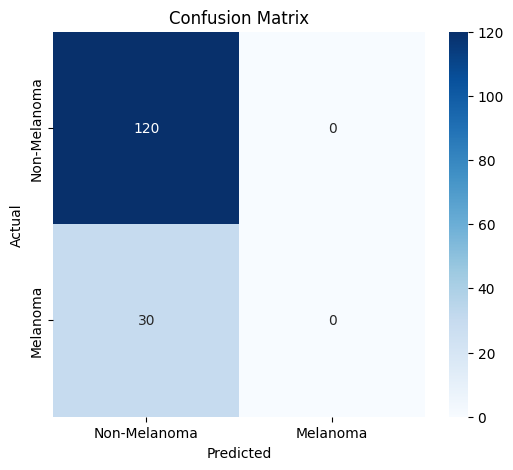


Classification Report:
              precision    recall  f1-score   support

Non-Melanoma       0.80      1.00      0.89       120
    Melanoma       0.00      0.00      0.00        30

    accuracy                           0.80       150
   macro avg       0.40      0.50      0.44       150
weighted avg       0.64      0.80      0.71       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# True labels
y_true = val_df["label"].values

# Predicted probabilities
y_pred_prob = model.predict(val_ds).ravel()

# Convert to binary predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:")
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Non-Melanoma", "Melanoma"],
            yticklabels=["Non-Melanoma", "Melanoma"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Non-Melanoma", "Melanoma"]))